In [64]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import timm

In [65]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

DATA_ROOT = "/Users/yaseenahmed/Downloads/MRNet-v1.0"
OOD_ROOT  = "/Users/yaseenahmed/Documents/EEEM068-MRNet-ViT/OOD_images"

PLANES = ["sagittal", "coronal", "axial"]

IMG_SIZE = 224
BATCH_SIZE = 4
NUM_EPOCHS = 20
LEARNING_RATE = 2e-5
NUM_WORKERS = 0
NUM_SLICES = 2
THRESHOLD = 0.5
BEST_MODEL_PATH = "best_multiplane_vit_cls.pth"

Using device: mps


In [66]:
def load_labels(data_root, split):
    abnormal_path = os.path.join(data_root, f"{split}-abnormal.csv")
    acl_path = os.path.join(data_root, f"{split}-acl.csv")
    meniscus_path = os.path.join(data_root, f"{split}-meniscus.csv")

    abnormal_df = pd.read_csv(abnormal_path, header=None, names=["id", "abnormal"])
    acl_df = pd.read_csv(acl_path, header=None, names=["id", "acl"])
    meniscus_df = pd.read_csv(meniscus_path, header=None, names=["id", "meniscus"])

    merged_df = abnormal_df.merge(acl_df, on="id").merge(meniscus_df, on="id")

    labels = {}
    for _, row in merged_df.iterrows():
        exam_id = f"{int(row['id']):04d}"
        labels[exam_id] = [
            float(row["abnormal"]),
            float(row["acl"]),
            float(row["meniscus"])
        ]

    return labels

In [67]:
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

valid_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [68]:
class FocalBCEWithLogitsLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, pos_weight=None, reduction='mean'):
        super().__init__()
        self.gamma      = gamma
        self.alpha      = alpha
        self.pos_weight = pos_weight
        self.reduction  = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=self.pos_weight,
            reduction='none'
        )
        probs        = torch.sigmoid(logits)
        p_t          = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma

        if self.alpha is not None:
            focal_weight = self.alpha * focal_weight

        loss = focal_weight * bce
        return loss.mean() if self.reduction == 'mean' else loss.sum()

In [69]:
class MRNetMultiPlaneDataset(Dataset):
    def __init__(self, data_root, split="train", num_slices=3, transform=None):
        self.data_root = data_root
        self.split = split
        self.num_slices = num_slices
        self.transform = transform
        self.planes = ["sagittal", "coronal", "axial"]

        self.labels = load_labels(data_root, split)
        self.exam_ids = sorted(list(self.labels.keys()))

    def __len__(self):
        return len(self.exam_ids)

    def normalize_slice(self, img):
        img = img.astype(np.float32)
        img_min = img.min()
        img_max = img.max()

        if img_max - img_min > 1e-8:
            img = (img - img_min) / (img_max - img_min)
        else:
            img = np.zeros_like(img, dtype=np.float32)

        img = (img * 255.0).clip(0, 255).astype(np.uint8)
        return img

    def get_slice_indices(self, num_total_slices):
        if self.num_slices >= num_total_slices:
            return np.arange(num_total_slices)
        return np.linspace(0, num_total_slices - 1, self.num_slices, dtype=int)

    def load_plane_volume(self, exam_id, plane):
        volume_path = os.path.join(self.data_root, self.split, plane, f"{exam_id}.npy")
        volume = np.load(volume_path)

        slice_indices = self.get_slice_indices(volume.shape[0])
        slice_tensors = []

        for s_idx in slice_indices:
            img = volume[s_idx]
            img = self.normalize_slice(img)
            pil_img = Image.fromarray(img).convert("RGB")

            if self.transform:
                pil_img = self.transform(pil_img)

            slice_tensors.append(pil_img)

        return torch.stack(slice_tensors, dim=0)  # (S, 3, H, W)

    def __getitem__(self, idx):
        exam_id = self.exam_ids[idx]

        sagittal = self.load_plane_volume(exam_id, "sagittal")
        coronal = self.load_plane_volume(exam_id, "coronal")
        axial = self.load_plane_volume(exam_id, "axial")

        label = torch.tensor(self.labels[exam_id], dtype=torch.float32)

        return sagittal, coronal, axial, label, exam_id

In [70]:
train_dataset = MRNetMultiPlaneDataset(
    data_root=DATA_ROOT,
    split="train",
    num_slices=NUM_SLICES,
    transform=train_transform
)

valid_dataset = MRNetMultiPlaneDataset(
    data_root=DATA_ROOT,
    split="valid",
    num_slices=NUM_SLICES,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))

Train samples: 1130
Valid samples: 120


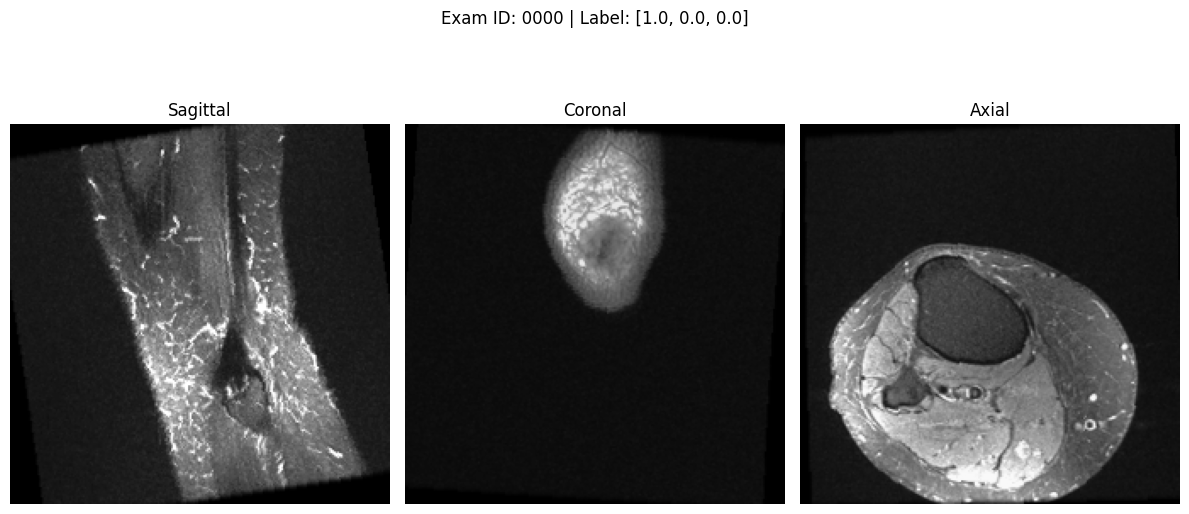

In [71]:
def denormalize_image(tensor_img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

sagittal, coronal, axial, label, exam_id = train_dataset[0]

plane_dict = {
    "Sagittal": sagittal,
    "Coronal": coronal,
    "Axial": axial
}

plt.figure(figsize=(12, 6))
plot_idx = 1

for plane_name, plane_tensor in plane_dict.items():
    mid_slice = len(plane_tensor) // 2
    plt.subplot(1, 3, plot_idx)
    plt.imshow(denormalize_image(plane_tensor[mid_slice]))
    plt.title(f"{plane_name}")
    plt.axis("off")
    plot_idx += 1

plt.suptitle(f"Exam ID: {exam_id} | Label: {label.tolist()}")
plt.tight_layout()
plt.show()

In [72]:
def compute_pos_weights(dataset):
    all_labels = []

    for i in range(len(dataset)):
        _, _, _, label, _ = dataset[i]
        all_labels.append(label.numpy())

    all_labels = np.array(all_labels)
    positives = all_labels.sum(axis=0)
    negatives = len(all_labels) - positives

    pos_weight = negatives / (positives + 1e-8)
    return torch.tensor(pos_weight, dtype=torch.float32)

pos_weights = compute_pos_weights(train_dataset).to(DEVICE)
print("Positive class weights:", pos_weights)

Positive class weights: tensor([0.2377, 4.4327, 1.8463], device='mps:0')


In [73]:
model = ViTMultiPlaneFusion(num_classes=3).to(DEVICE)

# Freeze everything
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer blocks
for block in model.backbone.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# Unfreeze head
for param in model.backbone.head.parameters():
    param.requires_grad = True

# Focal Loss replacing BCEWithLogitsLoss
criterion = FocalBCEWithLogitsLoss(
    gamma=2.0,
    pos_weight=pos_weights
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model)

ViTMultiPlaneFusion(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
  

In [74]:
model = ViTMultiPlaneFusion(num_classes=3).to(DEVICE)

criterion = FocalBCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model)

ViTMultiPlaneFusion(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
  

In [75]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for sagittal, coronal, axial, labels, _ in tqdm(loader, desc="Training", leave=False):
        sagittal = sagittal.to(device)
        coronal = coronal.to(device)
        axial = axial.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(sagittal, coronal, axial)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

    return total_loss / len(loader.dataset)

In [76]:
model = ViTMultiPlaneFusion(num_classes=3).to(DEVICE)

for param in model.backbone.parameters():
    param.requires_grad = False

# unfreeze only last 2 transformer blocks
for block in model.backbone.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# unfreeze head
for param in model.backbone.head.parameters():
    param.requires_grad = True

In [77]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [78]:
class ViTMultiPlaneFusion(nn.Module):
    def __init__(self, model_name="vit_small_patch16_224", num_classes=3, dropout=0.3):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes
        )
        self.dropout = nn.Dropout(dropout)

    def forward_one_plane(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        logits = self.backbone(x)
        logits = logits.view(B, S, -1)

        logits = logits.mean(dim=1)
        logits = self.dropout(logits)
        return logits

    def forward(self, sagittal, coronal, axial):
        sag_logits = self.forward_one_plane(sagittal)
        cor_logits = self.forward_one_plane(coronal)
        axi_logits = self.forward_one_plane(axial)

        fused_logits = (sag_logits + cor_logits + axi_logits) / 3.0
        return fused_logits

In [79]:
def evaluate_model(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0

    all_labels = []
    all_probs  = []
    all_preds  = []
    all_ids    = []

    with torch.no_grad():
        for sagittal, coronal, axial, labels, exam_ids in tqdm(loader, desc="Evaluating", leave=False):
            sagittal = sagittal.to(device)
            coronal  = coronal.to(device)
            axial    = axial.to(device)
            labels   = labels.to(device)

            outputs = model(sagittal, coronal, axial)
            loss    = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()

            total_loss += loss.item() * labels.size(0)

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_ids.extend(exam_ids)

    avg_loss   = total_loss / len(loader.dataset)
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs  = np.concatenate(all_probs,  axis=0)
    all_preds  = np.concatenate(all_preds,  axis=0)

    class_names = ["abnormal", "acl", "meniscus"]
    metrics = {}

    for i, class_name in enumerate(class_names):
        y_true = all_labels[:, i]
        y_prob = all_probs[:, i]
        y_pred = all_preds[:, i]

        intersection = np.logical_and(y_true, y_pred).sum()
        union        = np.logical_or(y_true, y_pred).sum()
        iou          = intersection / (union + 1e-8)

        metrics[class_name] = {
            "accuracy"  : accuracy_score(y_true, y_pred),
            "precision" : precision_score(y_true, y_pred, zero_division=0),
            "recall"    : recall_score(y_true, y_pred, zero_division=0),
            "f1"        : f1_score(y_true, y_pred, zero_division=0),
            "iou"       : iou,
            "auc_roc"   : roc_auc_score(y_true, y_prob)
        }

    return avg_loss, metrics, all_labels, all_probs, all_preds, all_ids

In [80]:
train_losses = []
valid_losses = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    valid_loss, valid_metrics, all_labels, all_probs, all_preds, all_ids = evaluate_model(
        model, valid_loader, criterion, DEVICE, threshold=THRESHOLD
    )

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")

    for cls, cls_metrics in valid_metrics.items():
        print(f"\n{cls.upper()}")
        for metric_name, metric_value in cls_metrics.items():
            print(f"  {metric_name}: {metric_value:.4f}")

    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"\nSaved best model to: {BEST_MODEL_PATH}")

print(f"\nBest validation loss: {best_val_loss:.4f} at epoch {best_epoch}")


Epoch 1/20


/var/folders/p4/cp7wz8hx5r91wbwpbs2q7brh0000gn/T/ipykernel_8918/1384901846.py:15: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Train Loss: 0.2062
Valid Loss: 0.2163

ABNORMAL
  accuracy: 0.7833
  precision: 0.8286
  recall: 0.9158
  f1: 0.8700
  iou: 0.7699
  auc_roc: 0.6695

ACL
  accuracy: 0.4750
  precision: 0.4615
  recall: 1.0000
  f1: 0.6316
  iou: 0.4615
  auc_roc: 0.6083

MENISCUS
  accuracy: 0.5250
  precision: 0.4713
  recall: 0.7885
  f1: 0.5899
  iou: 0.4184
  auc_roc: 0.5656

Saved best model to: best_multiplane_vit_cls.pth

Epoch 2/20


Train Loss: 0.1903
Valid Loss: 0.2330

ABNORMAL
  accuracy: 0.7833
  precision: 0.8710
  recall: 0.8526
  f1: 0.8617
  iou: 0.7570
  auc_roc: 0.6851

ACL
  accuracy: 0.6250
  precision: 0.5616
  recall: 0.7593
  f1: 0.6457
  iou: 0.4767
  auc_roc: 0.6557

MENISCUS
  accuracy: 0.5250
  precision: 0.4742
  recall: 0.8846
  f1: 0.6174
  iou: 0.4466
  auc_roc: 0.5888

Epoch 3/20


Train Loss: 0.1837
Valid Loss: 0.2767

ABNORMAL
  accuracy: 0.4667
  precision: 0.8605
  recall: 0.3895
  f1: 0.5362
  iou: 0.3663
  auc_roc: 0.7002

ACL
  accuracy: 0.5833
  precision: 0.6667
  recall: 0.1481
  f1: 0.2424
  iou: 0.1379
  auc_roc: 0.7175

MENISCUS
  accuracy: 0.6167
  precision: 0.5750
  recall: 0.4423
  f1: 0.5000
  iou: 0.3333
  auc_roc: 0.6290

Epoch 4/20


...

Train Loss: 0.1398
Valid Loss: 0.3565

ABNORMAL
  accuracy: 0.7333
  precision: 0.8987
  recall: 0.7474
  f1: 0.8161
  iou: 0.6893
  auc_roc: 0.7857

ACL
  accuracy: 0.5917
  precision: 0.7778
  recall: 0.1296
  f1: 0.2222
  iou: 0.1250
  auc_roc: 0.7783

MENISCUS
  accuracy: 0.7000
  precision: 0.6176
  recall: 0.8077
  f1: 0.7000
  iou: 0.5385
  auc_roc: 0.7548

Epoch 17/20


Train Loss: 0.1394
Valid Loss: 0.2362

ABNORMAL
  accuracy: 0.8167
  precision: 0.8925
  recall: 0.8737
  f1: 0.8830
  iou: 0.7905
  auc_roc: 0.7928

ACL
  accuracy: 0.6333
  precision: 0.6136
  recall: 0.5000
  f1: 0.5510
  iou: 0.3803
  auc_roc: 0.7660

MENISCUS
  accuracy: 0.6667
  precision: 0.6875
  recall: 0.4231
  f1: 0.5238
  iou: 0.3548
  auc_roc: 0.7525

Epoch 18/20


Train Loss: 0.1352
Valid Loss: 0.2993

ABNORMAL
  accuracy: 0.8000
  precision: 0.8901
  recall: 0.8526
  f1: 0.8710
  iou: 0.7714
  auc_roc: 0.8008

ACL
  accuracy: 0.6250
  precision: 0.7647
  recall: 0.2407
  f1: 0.3662
  iou: 0.2241
  auc_roc: 0.7722

MENISCUS
  accuracy: 0.6917
  precision: 0.6531
  recall: 0.6154
  f1: 0.6337
  iou: 0.4638
  auc_roc: 0.7520

Epoch 19/20


Train Loss: 0.1305
Valid Loss: 0.2406

ABNORMAL
  accuracy: 0.8167
  precision: 0.8925
  recall: 0.8737
  f1: 0.8830
  iou: 0.7905
  auc_roc: 0.8076

ACL
  accuracy: 0.6333
  precision: 0.6316
  recall: 0.4444
  f1: 0.5217
  iou: 0.3529
  auc_roc: 0.7674

MENISCUS
  accuracy: 0.7000
  precision: 0.6111
  recall: 0.8462
  f1: 0.7097
  iou: 0.5500
  auc_roc: 0.7636

Epoch 20/20


Train Loss: 0.1284
Valid Loss: 0.2400

ABNORMAL
  accuracy: 0.8250
  precision: 0.8491
  recall: 0.9474
  f1: 0.8955
  iou: 0.8108
  auc_roc: 0.8109

ACL
  accuracy: 0.6833
  precision: 0.7000
  recall: 0.5185
  f1: 0.5957
  iou: 0.4242
  auc_roc: 0.7795

MENISCUS
  accuracy: 0.6750
  precision: 0.5890
  recall: 0.8269
  f1: 0.6880
  iou: 0.5244
  auc_roc: 0.7534

Best validation loss: 0.2003 at epoch 15


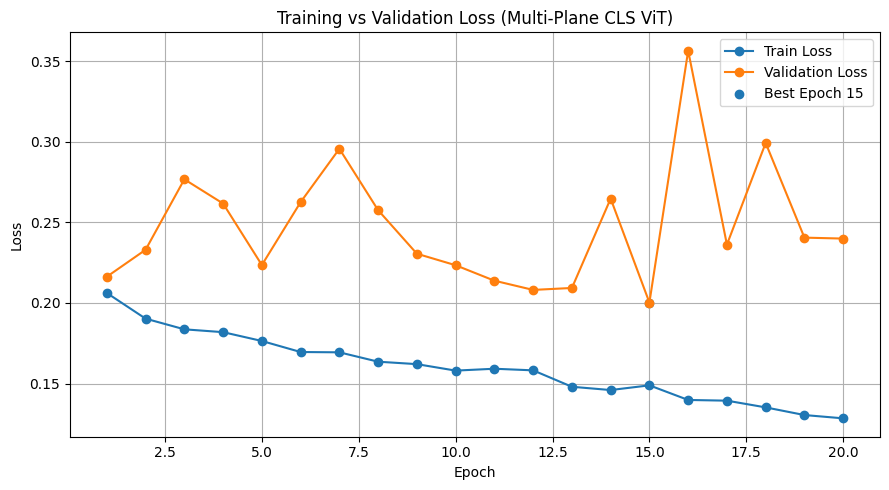

In [81]:
epochs = range(1, len(train_losses) + 1)
best_val = min(valid_losses)

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, valid_losses, marker='o', label="Validation Loss")
plt.scatter(best_epoch, best_val, label=f"Best Epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Multi-Plane CLS ViT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [82]:
best_model = ViTMultiPlaneFusion(num_classes=3).to(DEVICE)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.eval()

valid_loss, valid_metrics, all_labels, all_probs, all_preds, all_ids = evaluate_model(
    best_model, valid_loader, criterion, DEVICE, threshold=THRESHOLD
)

print("Final Validation Loss:", valid_loss)

for cls, cls_metrics in valid_metrics.items():
    print(f"\n{cls.upper()}")
    for metric_name, metric_value in cls_metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")

Final Validation Loss: 0.2002727050334215

ABNORMAL
  accuracy: 0.8000
  precision: 0.8901
  recall: 0.8526
  f1: 0.8710
  iou: 0.7714
  auc_roc: 0.7768

ACL
  accuracy: 0.6833
  precision: 0.6000
  recall: 0.8889
  f1: 0.7164
  iou: 0.5581
  auc_roc: 0.7531

MENISCUS
  accuracy: 0.6250
  precision: 0.5422
  recall: 0.8654
  f1: 0.6667
  iou: 0.5000
  auc_roc: 0.7254


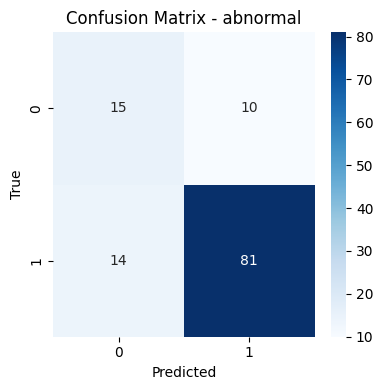

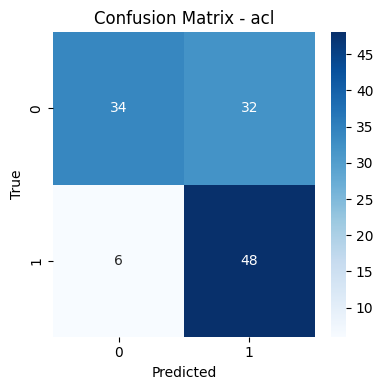

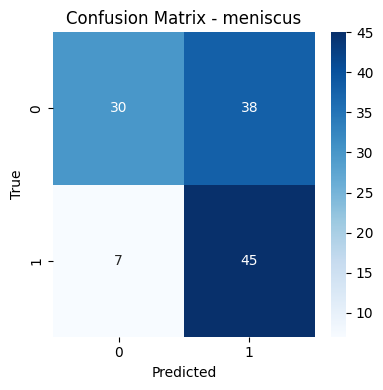

In [83]:
class_names = ["abnormal", "acl", "meniscus"]

for i, class_name in enumerate(class_names):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {class_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [84]:
results_df = pd.DataFrame({
    "exam_id": all_ids,

    "abnormal_true": all_labels[:, 0],
    "abnormal_prob": all_probs[:, 0],
    "abnormal_pred": all_preds[:, 0],

    "acl_true": all_labels[:, 1],
    "acl_prob": all_probs[:, 1],
    "acl_pred": all_preds[:, 1],

    "meniscus_true": all_labels[:, 2],
    "meniscus_prob": all_probs[:, 2],
    "meniscus_pred": all_preds[:, 2],
})

results_df.to_csv("multiplane_validation_predictions.csv", index=False)
print("Saved multiplane_validation_predictions.csv")

Saved multiplane_validation_predictions.csv


In [85]:
class OODImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = sorted(
            glob.glob(os.path.join(image_dir, "*.png")) +
            glob.glob(os.path.join(image_dir, "*.jpg")) +
            glob.glob(os.path.join(image_dir, "*.jpeg"))
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, os.path.basename(image_path)

In [86]:
def run_ood_inference_multiplane(model, image_dir, transform, device, threshold=0.5):
    model.eval()

    ood_dataset = OODImageDataset(image_dir=image_dir, transform=transform)

    results = []
    class_names = ["abnormal", "acl", "meniscus"]

    with torch.no_grad():
        for image, filename in ood_dataset:
            # Make one image act like 3 planes, 1 slice each:
            # sagittal=(1,1,3,H,W), coronal=(1,1,3,H,W), axial=(1,1,3,H,W)
            image = image.unsqueeze(0).unsqueeze(0).to(device)

            outputs = model(image, image, image)
            probs = torch.sigmoid(outputs).squeeze(0).cpu().numpy()
            preds = (probs >= threshold).astype(int)

            result = {"filename": filename}
            for i, class_name in enumerate(class_names):
                result[f"{class_name}_prob"] = float(probs[i])
                result[f"{class_name}_pred"] = int(preds[i])

            results.append(result)

    return pd.DataFrame(results)

In [87]:
ood_results_df = run_ood_inference_multiplane(
    model=best_model,
    image_dir=OOD_ROOT,
    transform=valid_transform,
    device=DEVICE,
    threshold=THRESHOLD
)

ood_results_df

,filename,abnormal_prob,abnormal_pred,acl_prob,acl_pred,meniscus_prob,meniscus_pred
0,Acl_sag.jpg,0.453192,0,0.463945,0,0.498388,0
1,Acl_sag2.jpeg,0.544144,1,0.696624,1,0.639779,1
2,Meni_sag_2.jpg,0.830517,1,0.715256,1,0.776538,1
3,meni_coronal_1.png,0.423882,0,0.653307,1,0.322402,0
4,meni_sag_1.jpg,0.919864,1,0.828596,1,0.792806,1
5,normal_coronal.jpeg,0.174914,0,0.205346,0,0.616982,1
6,normal_sag_2.jpeg,0.220265,0,0.367733,0,0.777910,1


In [88]:
ood_results_df.to_csv("multiplane_ood_predictions.csv", index=False)
print("Saved multiplane_ood_predictions.csv")

Saved multiplane_ood_predictions.csv


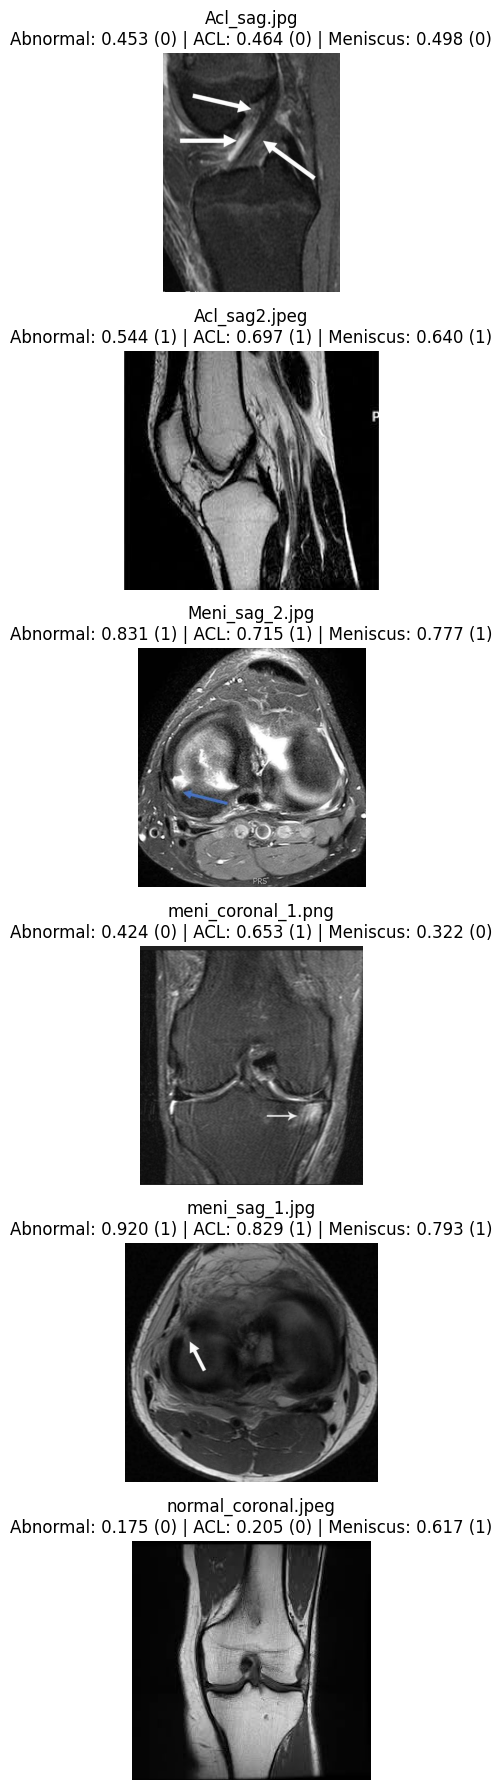

In [89]:
def show_ood_predictions(ood_root, results_df, max_images=6):
    image_files = results_df["filename"].tolist()[:max_images]

    plt.figure(figsize=(15, 3 * max_images))

    for i, filename in enumerate(image_files):
        image_path = os.path.join(ood_root, filename)
        img = Image.open(image_path).convert("RGB")

        row = results_df[results_df["filename"] == filename].iloc[0]

        title = (
            f"{filename}\n"
            f"Abnormal: {row['abnormal_prob']:.3f} ({row['abnormal_pred']}) | "
            f"ACL: {row['acl_prob']:.3f} ({row['acl_pred']}) | "
            f"Meniscus: {row['meniscus_prob']:.3f} ({row['meniscus_pred']})"
        )

        plt.subplot(max_images, 1, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ood_predictions(OOD_ROOT, ood_results_df, max_images=min(6, len(ood_results_df)))

In [90]:
metrics_rows = []
for cls, cls_metrics in valid_metrics.items():
    row = {"class": cls}
    row.update(cls_metrics)
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,class,accuracy,precision,recall,f1,iou,auc_roc
0,abnormal,0.800000,0.890110,0.852632,0.870968,0.771429,0.776842
1,acl,0.683333,0.600000,0.888889,0.716418,0.558140,0.753086
2,meniscus,0.625000,0.542169,0.865385,0.666667,0.500000,0.725396


In [91]:
metrics_df.to_csv("multiplane_validation_metrics.csv", index=False)
print("Saved multiplane_validation_metrics.csv")

Saved multiplane_validation_metrics.csv
